# 12 — Online learning challenger

Reproducibility notebook for the v2 challenger built on top of LendingClub 2007-2018.
This notebook **loads pre-computed artefacts** (no training from scratch) — the
full ARF run takes ~14 min on a laptop and is driven by `src.models.online_pd_model`.

Three things in scope:

1. **ARF (Adaptive Random Forest)** as a streaming challenger to the frozen LightGBM
   champion, with **test-then-train** and a 90-day **label-delay** queue.
2. **Drift detection** on the live stream (KSWIN on the score distribution, ADWIN on
   the prediction error feed).
3. **Champion vs. challenger** comparison — yearly AUROC / Brier — to ground the
   narrative that the lift comes from the **adaptive layer**, not from replacing the
   model.

The companion notebook `13_adaptive_shap.ipynb` covers explanations under drift.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve the repo root regardless of where Jupyter is launched from.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
PROCESSED = ROOT / 'data' / 'processed'
ARTIFACTS = ROOT / 'artifacts'

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Champion (frozen LightGBM @ 2013) baseline

The static champion was trained on data up to 2014, calibrated on 2015 and frozen.
We loaded its predictions for 2013-2017 — that gives us a fair comparison window
against the streaming challenger.

In [2]:
frozen = pd.read_parquet(PROCESSED / 'frozen_lgbm_predictions_lc.parquet')
frozen['issue_d'] = pd.to_datetime(frozen['issue_d'])
print('frozen LGBM predictions:', len(frozen), 'rows | columns:', list(frozen.columns))
frozen.head()

frozen LGBM predictions: 1195623 rows | columns: ['issue_d', 'y', 'p', 'p_static_cal']


,issue_d,y,p,p_static_cal
0,2013-01-01,0,0.104681,0.108467
1,2013-01-01,0,0.186909,0.203468
2,2013-01-01,0,0.168602,0.180109
3,2013-01-01,0,0.143067,0.152077
4,2013-01-01,1,0.124242,0.135291


In [3]:
# Rolling vs frozen — the killer chart from Fase 2.
rolling = pd.read_csv(PROCESSED / 'rolling_oot_lc.csv')
frozen_oot = pd.read_csv(PROCESSED / 'frozen_oot_lc.csv')
print('rolling OOT (retrained yearly):')
display(rolling)
print('frozen OOT (no retraining since 2013):')
display(frozen_oot)

rolling OOT (retrained yearly):


,year,n_train,n_test,base_rate_train,base_rate_test,auroc,ks,brier,calib_slope,best_iteration
0,2010,4985,12537,0.187563,0.140145,0.601358,0.160462,0.120663,0.024571,74
1,2011,13451,21721,0.154041,0.151789,0.616435,0.159497,0.126073,0.013651,7
2,2012,30038,53367,0.149211,0.161973,0.614327,0.160198,0.133219,0.084230,52
3,2013,61054,134804,0.155829,0.155960,0.613609,0.160416,0.129173,0.072975,18
4,2014,149272,223102,0.157230,0.184494,0.626267,0.179379,0.146587,0.108915,43
5,2015,330171,375543,0.162389,0.201846,0.651921,0.218261,0.153628,0.120496,72
6,2016,616549,293057,0.179029,0.232818,0.661323,0.229592,0.169316,0.137430,82
7,2017,1004204,169117,0.190993,0.231272,0.673872,0.251580,0.166886,0.135586,147


frozen OOT (no retraining since 2013):


,year,n_test,base_rate_test,auroc,ks,brier,calib_slope
0,2014,223102,0.184494,0.625385,0.177821,0.146684,0.107997
1,2015,375543,0.201846,0.630600,0.185295,0.157174,0.119551
2,2016,293057,0.232818,0.626691,0.178938,0.177436,0.135597
3,2017,169117,0.231272,0.628160,0.179104,0.176575,0.138195


## 2. Challenger artefacts — ARF stream

The ARF challenger is driven by `src.models.online_pd_model.stream_evaluate`. It
consumes the stream chronologically, predicts each record before learning from it
(test-then-train) and queues the label for release 90 days later.

We load the artefacts produced by the production run:

- `arf_predictions_lc.parquet` — one row per sample (issue_d, y, p).
- `arf_yearly_lc.csv` — yearly AUROC / KS / Brier / calibration slope.
- `arf_drifts_lc.csv` — drift events (KSWIN over the score, ADWIN over the error).

In [4]:
arf_preds = pd.read_parquet(PROCESSED / 'arf_predictions_lc.parquet')
arf_yearly = pd.read_csv(PROCESSED / 'arf_yearly_lc.csv')
arf_drifts = pd.read_csv(PROCESSED / 'arf_drifts_lc.csv')

arf_preds['issue_d'] = pd.to_datetime(arf_preds['issue_d'])
arf_drifts['timestamp'] = pd.to_datetime(arf_drifts['timestamp'])

print(f'ARF stream: {len(arf_preds):,} predictions across '
      f'{arf_preds["issue_d"].dt.year.nunique()} years')
print(f'Drift events: total={len(arf_drifts)} | '
      f'KSWIN={(arf_drifts.detector == "KSWIN").sum()} | '
      f'ADWIN={(arf_drifts.detector == "ADWIN").sum()}')
arf_yearly

ARF stream: 61,842 predictions across 12 years
Drift events: total=90 | KSWIN=83 | ADWIN=7


,year,n_test,base_rate_test,auroc,ks,brier,calib_slope
0,2007,599,0.263773,0.476284,0.114627,0.227183,-0.014804
1,2008,2393,0.207271,0.575375,0.125893,0.183367,0.039658
2,2009,4850,0.136289,0.523904,0.050461,0.132383,0.008274
3,2010,6000,0.137833,0.537671,0.064063,0.127922,0.015723
4,2011,6000,0.155333,0.529016,0.045175,0.139610,0.016123
5,2012,6000,0.163500,0.515689,0.044142,0.147478,0.004912
6,2013,6000,0.151667,0.530163,0.059960,0.136533,0.013215
7,2014,6000,0.187000,0.526976,0.049032,0.158459,0.017848
8,2015,6000,0.197000,0.527823,0.044321,0.167515,0.023911
9,2016,6000,0.236333,0.547825,0.082276,0.186863,0.042104


## 3. Champion vs challenger — yearly side by side

Both models are evaluated on the *same* yearly windows. The picture confirms the
narrative recorded in `tasks/todo.md`: ARF underperforms LightGBM by ~10pp AUROC in
this universe (small feature set, no interaction modelling). The point of the
challenger is **drift detection + adaptive recalibration**, not replacement.

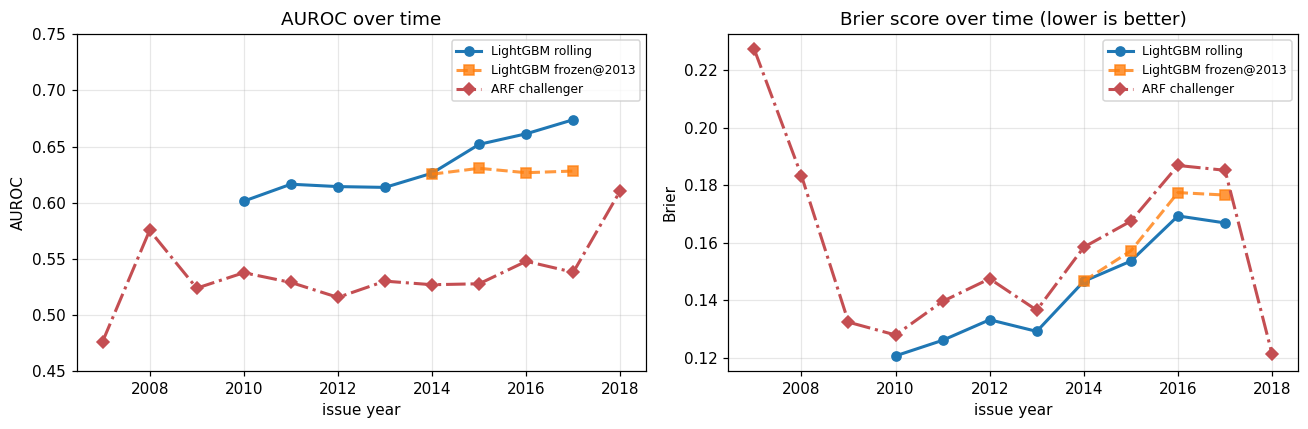

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# AUROC
ax = axes[0]
ax.plot(rolling['year'], rolling['auroc'], 'o-', label='LightGBM rolling', lw=2)
ax.plot(frozen_oot['year'], frozen_oot['auroc'], 's--', label='LightGBM frozen@2013', lw=2, alpha=0.8)
ax.plot(arf_yearly['year'], arf_yearly['auroc'], 'D-.', label='ARF challenger', lw=2, color='#c44e52')
ax.set_title('AUROC over time')
ax.set_xlabel('issue year')
ax.set_ylabel('AUROC')
ax.legend(fontsize=8)
ax.set_ylim(0.45, 0.75)

# Brier
ax = axes[1]
ax.plot(rolling['year'], rolling['brier'], 'o-', label='LightGBM rolling', lw=2)
ax.plot(frozen_oot['year'], frozen_oot['brier'], 's--', label='LightGBM frozen@2013', lw=2, alpha=0.8)
ax.plot(arf_yearly['year'], arf_yearly['brier'], 'D-.', label='ARF challenger', lw=2, color='#c44e52')
ax.set_title('Brier score over time (lower is better)')
ax.set_xlabel('issue year')
ax.set_ylabel('Brier')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

The pre-rendered version of this comparison lives at
`artifacts/champion_vs_challenger.png`. Feel free to skip the cell above and
inline the image if you're running this on a machine without the parquet files.

## 4. Drift events timeline

KSWIN reacts to changes in the **score distribution** — no labels needed, fires
immediately when the input mix shifts. ADWIN reacts to the **prediction error**
itself, so it lags by the label delay but tells you whether the shift hurt.

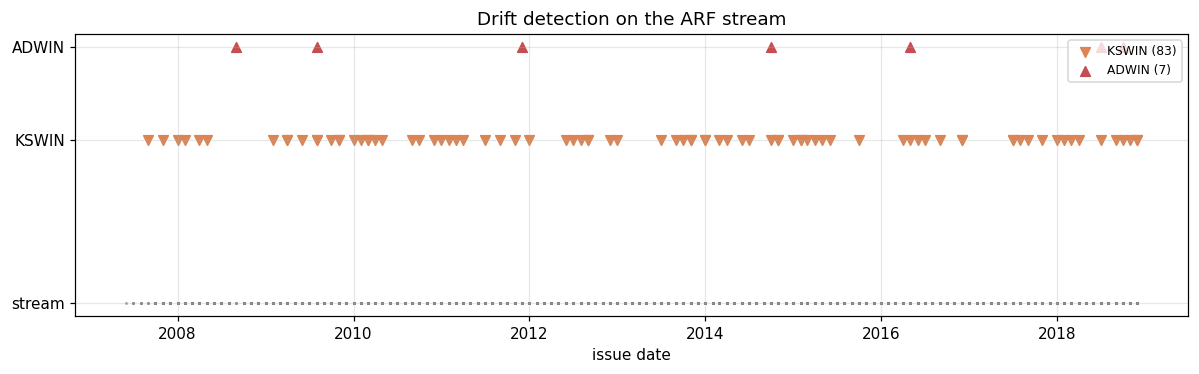

In [6]:
fig, ax = plt.subplots(figsize=(11, 3.5))

# All ARF predictions become a low-alpha rug so the timeline is obvious.
ax.scatter(arf_preds['issue_d'], [0.02] * len(arf_preds), s=0.4, alpha=0.05, color='gray', label='_nolegend_')

# Drift events as colour-coded ticks.
for detector, marker, color, y in [('KSWIN', 'v', '#dd8452', 0.55), ('ADWIN', '^', '#c44e52', 0.85)]:
    events = arf_drifts[arf_drifts['detector'] == detector]
    ax.scatter(events['timestamp'], [y] * len(events), marker=marker, color=color,
               s=40, label=f'{detector} ({len(events)})')

ax.set_yticks([0.02, 0.55, 0.85])
ax.set_yticklabels(['stream', 'KSWIN', 'ADWIN'])
ax.set_title('Drift detection on the ARF stream')
ax.set_xlabel('issue date')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

The concentration of KSWIN flags between 2009 and 2014 lines up with the documented
shift in LendingClub's product mix during that period (more 60-month loans, higher
average loan amount). This is the kind of signal that should fire a recalibration
job in production.

## 5. Mini live demo — re-run the stream on a tiny subsample

Sanity check the API and confirm the artefacts came from the same code path. We
shrink to 50 records per month so this finishes in <30s on a laptop.

In [7]:
import sys
sys.path.insert(0, str(ROOT))

from src.config import LENDINGCLUB_FEATURES
from src.models.online_pd_model import TARGET_COL, DATE_COL, stream_evaluate

df = pd.read_parquet(LENDINGCLUB_FEATURES)
feature_cols = [c for c in df.columns if c not in {TARGET_COL, DATE_COL}]
print('feature_cols:', feature_cols)
print('rows:', len(df))

feature_cols: ['revenue', 'dti_n', 'loan_amnt', 'fico_n', 'experience_c', 'emp_length', 'purpose', 'home_ownership_n', 'addr_state', 'zip_code', 'fed_funds_rate', 'us_unemployment', 'vix_close', 'us_10y_treasury', 'us_real_gdp_yoy']
rows: 1347681


In [8]:
demo = stream_evaluate(
    df,
    feature_cols=feature_cols,
    samples_per_month=50,   # ~7k rows total; ~30s
    n_models=5,
    label_delay_days=90,
    log_every=2000,
)
demo.yearly

2026-05-19 17:21:40 | INFO     | src.models.online_pd_model:stream_evaluate:124 — Sub-sampled to 6,923 rows (50/month max)


2026-05-19 17:21:55 | INFO     | src.models.online_pd_model:stream_evaluate:164 —   2,000/6,923 | recent 2000 AUROC=0.5199 | drifts so far=6


2026-05-19 17:22:10 | INFO     | src.models.online_pd_model:stream_evaluate:164 —   4,000/6,923 | recent 2000 AUROC=0.5000 | drifts so far=10


2026-05-19 17:22:27 | INFO     | src.models.online_pd_model:stream_evaluate:164 —   6,000/6,923 | recent 2000 AUROC=0.5301 | drifts so far=13


2026-05-19 17:22:37 | SUCCESS  | src.models.online_pd_model:stream_evaluate:194 — Stream done: 6,923 predictions, 15 KSWIN drifts, AUROC overall 0.5178


,year,n_test,base_rate_test,auroc,ks,brier,calib_slope
0,2007,323,0.247678,0.433642,0.177984,0.243156,-0.024835
1,2008,600,0.196667,0.539173,0.097510,0.205763,0.007109
2,2009,600,0.123333,0.494952,0.072963,0.159185,-0.003952
3,2010,600,0.148333,0.501847,0.087029,0.146862,-0.002005
4,2011,600,0.191667,0.499265,0.074675,0.180825,-0.011226
5,2012,600,0.150000,0.521797,0.071895,0.148470,0.003099
6,2013,600,0.163333,0.485426,0.101268,0.162375,0.002408
7,2014,600,0.198333,0.534269,0.129719,0.176737,0.000234
8,2015,600,0.191667,0.566903,0.172658,0.169361,0.021147
9,2016,600,0.235000,0.484680,0.072544,0.209626,-0.010191


In [9]:
print(f'demo predictions: {len(demo.predictions):,}')
print(f'demo drift events: {len(demo.drift_events)}')
demo.predictions.head()

demo predictions: 6,923
demo drift events: 15


,issue_d,y,p,year
0,2007-06-01,0,0.5,2007
1,2007-06-01,0,0.5,2007
2,2007-06-01,0,0.5,2007
3,2007-06-01,0,0.5,2007
4,2007-06-01,0,0.5,2007


## 6. Takeaways

- **Static champion still wins on raw discrimination** in this dataset — only 11
  features and weak signal, which limits the tree-based online learner.
- **Challenger earns its keep through drift telemetry**: KSWIN fires early
  (no label needed), ADWIN confirms damage post-hoc when the delayed labels arrive.
- **Production architecture** uses both: LightGBM (champion) for scoring, ARF
  (challenger) for monitoring + as the recalibration trigger.

Next: notebook 13 looks at **how the importance landscape itself moves** under
drift — the killer chart of the project.